# Week 9 : Recurrent Neural Network

Dataset contains Monthly and Daily prices of Natural gas, starting from January 1997 to current
year. Prices are in nominal dollars. The task is to predict the price of natural gas using RNN model
for the dataset

https://datahub.io/core/natural-gas#resource-daily or

https://www.kaggle.com/datasets/joebeachcapital/natural-gas-prices

Given the price of last ten 10 days, corresponds to sequence_length, the RNN model must predict
the price for the 11th day.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch import nn

In [12]:
df = pd.read_csv("./data/daily.csv")

# Preprocess the data - Drop NA values in the dataset
df = df.dropna()
y = df['Price'].values
x = np.arange(1, len(y), 1)
print(len(y))

# Normalize the input range between 0 and 1
minm = y.min()
maxm = y.max()
print(minm, maxm)
y = (y - minm) / (maxm - minm)
Sequence_Length = 10
X = []
Y = []
for i in range(0, 5900):
    list1 = []
    for j in range(i, i + Sequence_Length):
        list1.append(y[j])
        X.append(list1)
        Y.append(y[j + 1])


5952
1.05 18.48


In [20]:
X = np.array(X)
Y = np.array(Y)

x_train, x_test, y_train, y_test = train_test_split(X, Y,
test_size=0.10, random_state=42, shuffle=False, stratify=None)

class NGTimeSeries(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.len = x.shape[0]
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
    def __len__(self):
        return self.len
    
dataset = NGTimeSeries(x_train,y_train)

from torch.utils.data import DataLoader, Dataset

train_loader = DataLoader(dataset,shuffle=True,batch_size=256)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
class RNNModel(nn.Module):
    def __init__(self):
        super(RNNModel,self).__init__()
        self.rnn = nn.RNN(input_size=1,hidden_size=5,num_layers=1,batch_first=True)
        self.fc1 = nn.Linear(in_features=5,out_features=1)
    def forward(self,x):
        output,_status = self.rnn(x)
        output = output[:,-1,:]
        output = self.fc1(torch.relu(output))
        return output
model = RNNModel().to(device)# optimizer , loss
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
epochs = 1500

0th iteration: Loss = 0.007869821041822433
50th iteration: Loss = 0.0003912626998499036
100th iteration: Loss = 0.00019817282736767083
150th iteration: Loss = 0.0002414092159597203
200th iteration: Loss = 0.0005204934277571738
250th iteration: Loss = 0.00014677733997814357
300th iteration: Loss = 0.0003722824330907315
350th iteration: Loss = 0.0002583660534583032
400th iteration: Loss = 0.0003132027923129499
450th iteration: Loss = 0.00014619225112255663
500th iteration: Loss = 0.00015697168419137597
550th iteration: Loss = 0.002886153059080243
600th iteration: Loss = 0.00020773743744939566
650th iteration: Loss = 0.00019444273493718356
700th iteration: Loss = 0.00017875948105938733
750th iteration: Loss = 0.00016510093701072037
800th iteration: Loss = 0.00011225191701669246
850th iteration: Loss = 0.00296772550791502
900th iteration: Loss = 0.00042622204637154937
950th iteration: Loss = 0.00028038560412824154
1000th iteration: Loss = 0.00020152128126937896
1050th iteration: Loss = 0.0

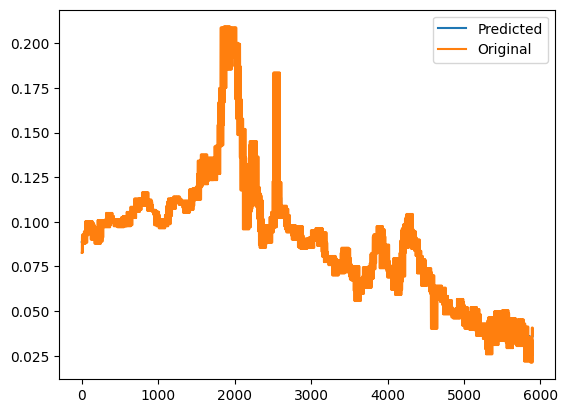

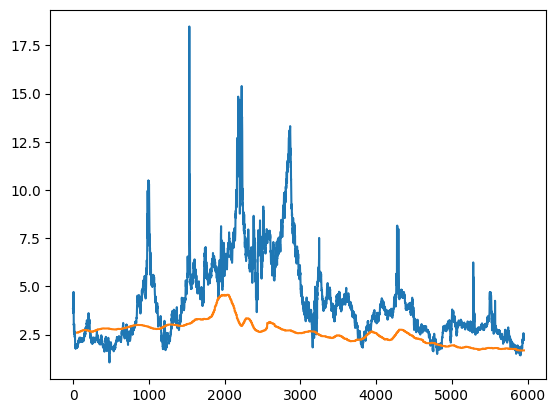

In [15]:
# training loop
for i in range(epochs):
    for j, data in enumerate(train_loader):
        inputs, targets = data
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Reshape inputs to the shape (batch_size, sequence_length, input_size)
        y_pred = model(inputs.view(-1, Sequence_Length, 1)).reshape(-1)
        
        # Compute loss
        loss = criterion(y_pred, targets)
        
        # Backpropagation and optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    if i % 50 == 0:
        print(f"{i}th iteration: Loss = {loss.item()}")

# Test set actual vs predicted
test_set = NGTimeSeries(x_test, y_test)
test_inputs, test_targets = test_set[:]
test_inputs, test_targets = test_inputs.to(device), test_targets.to(device)

# Predict
test_pred = model(test_inputs.view(-1, Sequence_Length, 1)).view(-1)

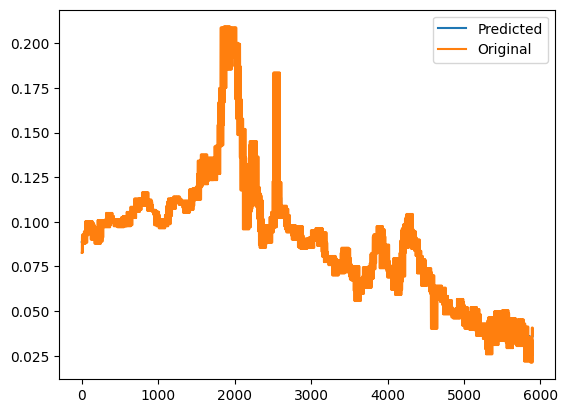

In [16]:
# Plot the results
plt.plot(test_pred.detach().cpu().numpy(), label='Predicted')
plt.plot(test_targets.view(-1).cpu().numpy(), label='Original')
plt.legend()
plt.show()

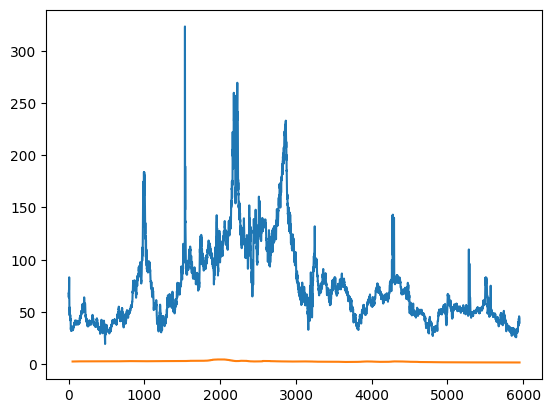

In [17]:
# Undo normalization for actual and predicted data
y = y * (maxm - minm) + minm
y_pred = test_pred.detach().cpu().numpy() * (maxm - minm) + minm

# Plot the entire time series with predictions
plt.plot(y)
plt.plot(range(len(y) - len(y_pred), len(y)), y_pred)
plt.show()

In [18]:
print(device)

cuda


Question 2) The data provided at the link https://download.pytorch.org/tutorial/data.zip consists of
names stored in the format {language: [names ...]} i.e. each language contains a list of
names. 

Train a RNN on a few thousand surnames from 18 languages of origin, and
predict which language a name is from based on the spelling

In [34]:
import os
import torch
import string
from torch.utils.data import Dataset, DataLoader
import random
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

data_dir = './data/names'

languages = [f for f in os.listdir(data_dir) if os.path.isfile(os.path.join(data_dir, f)) and f.endswith('.txt')]

all_letters = string.ascii_lowercase + " "
n_letters = len(all_letters)

char_to_index = {char: i for i, char in enumerate(all_letters)}
index_to_char = {i: char for i, char in enumerate(all_letters)}

def remove_accents(name):
    accents_map = {
        'à': 'a', 'á': 'a', 'ä': 'a', 'ã': 'a', 'â': 'a', 'å': 'a', 
        'è': 'e', 'é': 'e', 'ê': 'e', 'ë': 'e', 'í': 'i', 'ï': 'i',
        'ì': 'i', 'î': 'i', 'ó': 'o', 'ö': 'o', 'ò': 'o', 'ô': 'o',
        'õ': 'o', 'ú': 'u', 'ü': 'u', 'ù': 'u', 'û': 'u', 'ñ': 'n',
        'ç': 'c'
    }
    return ''.join(accents_map.get(c, c) for c in name.lower())

def name_to_tensor(name):
    name = remove_accents(name)  
    tensor = torch.zeros(len(name), 1, dtype=torch.long)
    for li, letter in enumerate(name):
        tensor[li][0] = char_to_index.get(letter, char_to_index[' '])  # Handle missing characters
    return tensor

language_data = {}
for language in languages:
    with open(os.path.join(data_dir, language), 'r', encoding='utf-8') as f:
        names = f.read().strip().splitlines()
        language_data[language] = names

In [35]:
class NameLanguageDataset(Dataset):
    def __init__(self, language_data):
        self.names_and_labels = [(name, lang) for lang, names in language_data.items() for name in names]
        random.shuffle(self.names_and_labels)  # Shuffle dataset

    def __len__(self):
        return len(self.names_and_labels)

    def __getitem__(self, idx):
        name, language = self.names_and_labels[idx]
        input_tensor = name_to_tensor(name)
        target_tensor = list(language_data.keys()).index(language)  # Get language index
        return input_tensor, target_tensor

def collate_fn(batch):
    input_tensors, target_tensors = zip(*batch)
    padded_inputs = torch.nn.utils.rnn.pad_sequence(input_tensors, batch_first=True, padding_value=char_to_index[' '])
    targets = torch.tensor(target_tensors, dtype=torch.long)
    return padded_inputs, targets

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, input_tensor):
        hidden = torch.zeros(1, input_tensor.size(0), self.hidden_size).to(input_tensor.device)
        output, _ = self.rnn(input_tensor, hidden)
        output = self.fc(output[:, -1, :])  # Use last output of the sequence
        return output


In [32]:
input_size = 1
hidden_size = 128
output_size = len(languages) 
learning_rate = 0.001
epochs = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RNNModel(input_size, hidden_size, output_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

dataset = NameLanguageDataset(language_data)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

for epoch in range(epochs):
    total_loss = 0
    for input_tensor, target_tensor in train_loader:
        input_tensor = input_tensor.to(torch.float32).to(device)
        target_tensor = target_tensor.to(device)

        output = model(input_tensor)

        loss = criterion(output, target_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(train_loader)}')

Epoch 10/100, Loss: 1.5492090330382062
Epoch 20/100, Loss: 1.270605780706284
Epoch 30/100, Loss: 1.146072200529135
Epoch 40/100, Loss: 1.0708221819750063
Epoch 50/100, Loss: 1.045539810968812
Epoch 60/100, Loss: 1.0218247154336066
Epoch 70/100, Loss: 0.9589187857831359
Epoch 80/100, Loss: 0.9274164859656315
Epoch 90/100, Loss: 0.9212231404462438
Epoch 100/100, Loss: 0.9097160404654825


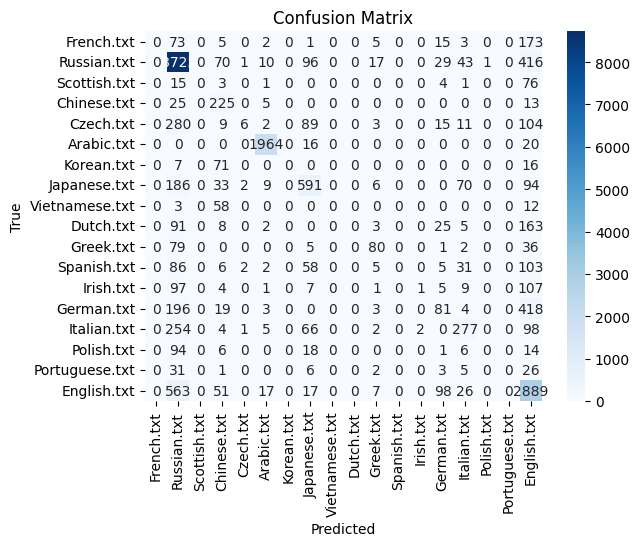

In [33]:
def evaluate_model(test_loader, model):
    model.eval()  
    all_preds, all_labels = [], []

    with torch.no_grad():
        for input_tensor, target_tensor in test_loader:
            input_tensor = input_tensor.to(torch.float32).to(device)
            target_tensor = target_tensor.to(device)
            
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(target_tensor.cpu().numpy())

    return all_labels, all_preds

def plot_confusion_matrix(true_labels, predicted_labels):
    cm = confusion_matrix(true_labels, predicted_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=languages, yticklabels=languages)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

true_labels, predicted_labels = evaluate_model(test_loader, model)
plot_confusion_matrix(true_labels, predicted_labels)


In [25]:
def predict_language(name, model):
    input_tensor = name_to_tensor(name).to(torch.float32).to(device)
    output = model(input_tensor.unsqueeze(0))  
    predicted_language_idx = torch.argmax(output).item()
    return languages[predicted_language_idx]

test_name = "garcia"
predicted_language = predict_language(test_name, model)
print(f"The predicted language for '{test_name}' is {predicted_language}")

The predicted language for 'garcia' is Russian.txt


Question 3) Implement a next character predictor using RNN Model

In [53]:
import urllib.request
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import string
from sklearn.model_selection import train_test_split

url = "https://www.gutenberg.org/files/100/100-0.txt"
response = urllib.request.urlopen(url)
text = response.read().decode('utf-8')

print(text[:500])
print(f"Length of raw text: {len(text)}")


*** START OF THE PROJECT GUTENBERG EBOOK 100 ***
The Complete Works of William Shakespeare

by William Shakespeare




                    Contents

    THE SONNETS
    ALL’S WELL THAT ENDS WELL
    THE TRAGEDY OF ANTONY AND CLEOPATRA
    AS YOU LIKE IT
    THE COMEDY OF ERRORS
    THE TRAGEDY OF CORIOLANUS
    CYMBELINE
    THE TRAGEDY OF HAMLET, PRINCE OF DENMARK
    THE FIRST PART OF KING HENRY THE FOURTH
    THE SECOND PART OF KING HENRY THE FOURTH
    THE LIFE OF KING HE
Length of raw text: 5555456


In [55]:
text = text.lower().replace('\n', ' ').replace('\r', '')  # Convert to lowercase and remove newlines
print(f"Length of cleaned text: {len(text)}")

unique_chars = sorted(list(set(text)))  
print(f"Unique characters in text: {unique_chars}")


Length of cleaned text: 5359439
Unique characters in text: ['\t', ' ', '!', '&', "'", '(', ')', '*', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'à', 'â', 'æ', 'ç', 'è', 'é', 'ê', 'ë', 'î', 'œ', '—', '‘', '’', '“', '”', '…']


In [56]:
char_to_idx = {char: idx for idx, char in enumerate(unique_chars)}
idx_to_char = {idx: char for idx, char in enumerate(unique_chars)}

encoded_text = [char_to_idx[char] for char in text if char in char_to_idx]
print(f"Length of encoded text: {len(encoded_text)}")

Sequence_Length = 10
X = []
Y = []

for i in range(len(encoded_text) - Sequence_Length):
    X.append(encoded_text[i:i + Sequence_Length])
    Y.append(encoded_text[i + Sequence_Length])

# Check lengths of X and Y
print(f"Length of X: {len(X)}")
print(f"Length of Y: {len(Y)}")


Length of encoded text: 5359439
Length of X: 5359429
Length of Y: 5359429


In [57]:
if len(X) == 0 or len(Y) == 0:
    raise ValueError("The sequences are empty. Please check the sequence generation logic.")

X = np.array(X)
Y = np.array(Y)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.10, random_state=42, shuffle=False)

class TextDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
        self.len = x.shape[0]
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
    
    def __len__(self):
        return self.len

class RNNModel(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # RNN layer
        self.rnn = nn.RNN(input_size=vocab_size, hidden_size=self.hidden_size, num_layers=self.num_layers, batch_first=True)
        
        # Output layer to predict the next character
        self.fc = nn.Linear(self.hidden_size, vocab_size)

    def forward(self, x):
        # One-hot encoding for each character index
        x = torch.nn.functional.one_hot(x, num_classes=len(char_to_idx)).float()  # One-hot encoding of input
        out, _ = self.rnn(x)  # RNN output
        out = self.fc(out[:, -1, :])  # Output for the last timestep
        return out

In [59]:
hidden_size = 64  
sequence_length = 5  
batch_size = 32
epochs = 20 

train_dataset = TextDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model = RNNModel(vocab_size=len(char_to_idx), hidden_size=hidden_size)
criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [61]:
limit_data_size = 5000

X_subset = X[:limit_data_size]
Y_subset = Y[:limit_data_size]

x_train, x_test, y_train, y_test = train_test_split(X_subset, Y_subset, test_size=0.1, random_state=42, shuffle=True)

train_dataset = TextDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)  # Forward pass
        loss = criterion(output, target)  # Calculate loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        
    if epoch % 5 == 0:  # Print every 5 epochs for quicker feedback
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item()}")


Epoch 0/20, Loss: 1.3365529775619507
Epoch 5/20, Loss: 1.159993052482605
Epoch 10/20, Loss: 1.4147584438323975
Epoch 15/20, Loss: 1.4773725271224976


In [63]:
def generate_sequence(model, seed, length=100):
    model.eval()
    generated_sequence = seed
    seed_idx = [char_to_idx[char] for char in seed]

    for _ in range(length):
        input_seq = torch.tensor(seed_idx).unsqueeze(0)  
        output = model(input_seq)
        _, predicted_idx = torch.max(output, dim=1)
        
        predicted_char = idx_to_char[predicted_idx.item()]
        generated_sequence += predicted_char
        
        # Update the seed sequence with the new character
        seed_idx.append(predicted_idx.item())
        seed_idx = seed_idx[1:]  # Keep the last 'sequence_length' characters
    
    return generated_sequence

seed = "this is a simple example to predict"
generated_text = generate_sequence(model, seed, length=20)
print("Generated Text:")
print(generated_text)


Generated Text:
this is a simple example to predicted winter winter win
